# Maduro Bets — Statistical Distribution Analysis

All trades across 8 Maduro-related markets fetched, saved to CSV, and analysed.
**Green = YES (bet Maduro captured/gone)  |  Red = NO (bet he stays)**

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import httpx, sys
import numpy as np
import polars as pl
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 10,
                     'axes.labelsize': 9, 'xtick.labelsize': 7,
                     'ytick.labelsize': 7, 'legend.fontsize': 7})

C_YES, C_NO = '#2ea043', '#cf222e'
EDA = Path('.')
sys.path.insert(0, str(EDA / '..'))

fmt_usdc = mticker.FuncFormatter(
    lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')

<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
<>:26: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95450/3482328490.py:25: SyntaxWarning: invalid escape sequence '\$'
  lambda v, _: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95450/3482328490.py:26: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95450/3482328490.py:26: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')


In [2]:
MARKETS = [
    {'question':'Maduro in U.S. custody by January 31?',
     'condition_id':'0xbfa45527ec959aacc36f7c312bd4f328171a7681ef1aeb3a7e34db5fb47d3f1d',
     'resolution':'No','volume_m':11.03},
    {'question':'Maduro out in 2025?',
     'condition_id':'0xafc235557ace53ff0b0d2e93392314a7c3f3daab26a79050e985c11282f66df7',
     'resolution':'No','volume_m':34.64},
    {'question':'Maduro out by January 31, 2026?',
     'condition_id':'0x580adc1327de9bf7c179ef5aaffa3377bb5cb252b7d6390b027172d43fd6f993',
     'resolution':'No','volume_m':10.97},
    {'question':'Maduro out by November 30, 2025?',
     'condition_id':'0xa953bea944d7264285c0a2cc1f92809a7d9db78138b1c3de9cc23d8917f14d6a',
     'resolution':'No','volume_m':5.57},
    {'question':'Maduro out by March 31, 2026?',
     'condition_id':'0x18d8c59309811ce5618ea941f9bde2a96afa5d876a69c42fba2da4bcc56d3c5e',
     'resolution':'No','volume_m':3.79},
    {'question':'Fact Check: Maduro capture staged?',
     'condition_id':'0x4cd373cd35f29c39a4fb45b7c31f8619d142aec0b4f863245510d1b3169c5502',
     'resolution':'No','volume_m':1.08},
    {'question':'Maduro in U.S. custody by December 31?',
     'condition_id':'0xc9aea75023b81578a98479326ebc8655ff61602a693f1f07930229eb1c496e0c',
     'resolution':'No','volume_m':0.38},
    {'question':'U.S. operation to capture Maduro in 2025?',
     'condition_id':'0x69ac865d7824f22808d29deec2ed5090eaeeb27094e6936970c4b4c5660a87d5',
     'resolution':'No','volume_m':0.12},
]

def fetch_trades(condition_id):
    rows, seen = [], set()
    with httpx.Client(base_url='https://data-api.polymarket.com', timeout=30) as client:
        for offset in range(0, 3000, 500):
            data = client.get('/trades',
                params={'market': condition_id, 'limit': 500, 'offset': offset}).json()
            if not isinstance(data, list) or not data: break
            for r in data:
                h = r.get('transactionHash', str(r.get('timestamp','')))
                if h not in seen:
                    seen.add(h)
                    rows.append(r)
            if len(data) < 500: break
    return rows

print('Fetching all Maduro markets...')
all_rows = []
for mkt in MARKETS:
    rows = fetch_trades(mkt['condition_id'])
    for r in rows:
        r['_question']   = mkt['question']
        r['_resolution'] = mkt['resolution']
        r['_volume_m']   = mkt['volume_m']
    all_rows.extend(rows)
    print(f'  {mkt["question"][:55]:<56} {len(rows):>4} fills')

print(f'\nTotal: {len(all_rows)} fills across {len(MARKETS)} markets')

Fetching all Maduro markets...


  Maduro in U.S. custody by January 31?                    2517 fills


  Maduro out in 2025?                                      3000 fills


  Maduro out by January 31, 2026?                          3000 fills


  Maduro out by November 30, 2025?                         3000 fills


  Maduro out by March 31, 2026?                            3000 fills


  Fact Check: Maduro capture staged?                       3000 fills
  Maduro in U.S. custody by December 31?                    766 fills


  U.S. operation to capture Maduro in 2025?                 531 fills

Total: 18814 fills across 8 markets


In [3]:
# Build DataFrame and save CSV
df = pl.DataFrame({
    'market':     [r['_question']   for r in all_rows],
    'resolution': [r['_resolution'] for r in all_rows],
    'side':       [str(r.get('side',''))    for r in all_rows],
    'outcome':    [str(r.get('outcome','')) for r in all_rows],
    'size':       [float(r.get('size', 0)) for r in all_rows],
    'price':      [float(r.get('price',0)) for r in all_rows],
    'timestamp':  [int(r.get('timestamp',0)) for r in all_rows],
    'wallet':     [str(r.get('proxyWallet','')) for r in all_rows],
    'tx_hash':    [str(r.get('transactionHash','')) for r in all_rows],
})

# Normalise outcome
df = df.with_columns(
    pl.when(pl.col('outcome').str.to_lowercase() == 'yes').then(pl.lit('Yes'))
      .when(pl.col('outcome').str.to_lowercase() == 'no').then(pl.lit('No'))
      .otherwise(pl.col('outcome')).alias('outcome')
)

df.write_csv(EDA / 'maduro_bets.csv')
print(f'Saved maduro_bets.csv  —  {len(df):,} rows')
df.head(3)

Saved maduro_bets.csv  —  18,814 rows


market,resolution,side,outcome,size,price,timestamp,wallet,tx_hash
str,str,str,str,f64,f64,i64,str,str
"""Maduro in U.S. custody by Janu…","""No""","""BUY""","""No""",1000.0,0.001,1767746717,"""0x79f0fd672a7fdd712440c2b8e533…","""0xea95a0c8d25d5eef9c99aa82236a…"
"""Maduro in U.S. custody by Janu…","""No""","""BUY""","""No""",10000.0,0.001,1767746093,"""0x36e8a41ce60310eae5568b9e0c80…","""0xc1fb212117075c0df0a6a127e4b7…"
"""Maduro in U.S. custody by Janu…","""No""","""BUY""","""No""",2.06,0.001,1767745571,"""0xa2b0d8ded1f7b0e33a40c116a7ac…","""0xeb2609b40f0b185e44d158d74dad…"


## Summary statistics — BUY orders only (new money)

In [4]:
buys = df.filter(pl.col('side') == 'BUY')

def stats_block(sizes, label):
    a = np.abs(sizes)  # absolute values
    if len(a) == 0:
        return {}
    return {
        'Label':    label,
        'Count':    len(a),
        'Sum':      f'${a.sum():,.0f}',
        'Mean':     f'${a.mean():,.0f}',
        'Median':   f'${np.median(a):,.0f}',
        'Std':      f'${a.std():,.0f}',
        'Skew':     f'{scipy_stats.skew(a):.2f}',
        'Kurt':     f'{scipy_stats.kurtosis(a):.2f}',
        'Min':      f'${a.min():,.0f}',
        'p25':      f'${np.percentile(a,25):,.0f}',
        'p75':      f'${np.percentile(a,75):,.0f}',
        'p95':      f'${np.percentile(a,95):,.0f}',
        'p99':      f'${np.percentile(a,99):,.0f}',
        'Max':      f'${a.max():,.0f}',
    }

yes_sizes = np.abs(buys.filter(pl.col('outcome') == 'Yes')['size'].to_numpy())
no_sizes  = np.abs(buys.filter(pl.col('outcome') == 'No' )['size'].to_numpy())
all_sizes = np.abs(buys['size'].to_numpy())

rows_stats = [stats_block(yes_sizes, 'YES bets (lost)'),
              stats_block(no_sizes,  'NO bets  (WON)'),
              stats_block(all_sizes, 'ALL bets')]

header = list(rows_stats[0].keys())
print(f'{"":22}' + ''.join(f'{h:>12}' for h in header[1:]))
print('-' * (22 + 12*len(header[1:])))
for r in rows_stats:
    print(f'{r["Label"]:<22}' + ''.join(f'{r[k]:>12}' for k in header[1:]))

                             Count         Sum        Mean      Median         Std        Skew        Kurt         Min         p25         p75         p95         p99         Max
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
YES bets (lost)               3888  $7,558,578      $1,944        $100     $12,855       21.49      671.81          $1         $20        $500      $6,303     $40,005    $500,000
NO bets  (WON)                8567 $13,255,302      $1,547         $20     $22,179       52.04     3170.59          $0          $3        $300      $4,000     $20,424  $1,509,322
ALL bets                     12455 $20,813,880      $1,671         $40     $19,748       52.55     3506.94          $0          $5        $352      $4,791     $25,715  $1,509,322


## Per-market stats table

In [5]:
print(f'{"Market":<45} {"Res":<4} {"YES bets":>9} {"YES sum":>12} {"NO bets":>9} {"NO sum":>12} {"Max bet":>12} {"Skew(YES)":>10} {"Skew(NO)":>10}')
print('-'*135)
for mkt in MARKETS:
    mkt_df = buys.filter(pl.col('market') == mkt['question'])
    yes_s = np.abs(mkt_df.filter(pl.col('outcome')=='Yes')['size'].to_numpy())
    no_s  = np.abs(mkt_df.filter(pl.col('outcome')=='No' )['size'].to_numpy())
    all_s = np.abs(mkt_df['size'].to_numpy())
    skew_yes = f'{scipy_stats.skew(yes_s):.1f}' if len(yes_s)>2 else 'n/a'
    skew_no  = f'{scipy_stats.skew(no_s):.1f}'  if len(no_s)>2  else 'n/a'
    max_b    = all_s.max() if len(all_s) else 0
    print(f'{mkt["question"][:44]:<45} {mkt["resolution"]:<4} '
          f'{len(yes_s):>9,} ${yes_s.sum():>10,.0f} '
          f'{len(no_s):>9,} ${no_s.sum():>10,.0f} '
          f'${max_b:>10,.0f} {skew_yes:>10} {skew_no:>10}')

Market                                        Res   YES bets      YES sum   NO bets       NO sum      Max bet  Skew(YES)   Skew(NO)
---------------------------------------------------------------------------------------------------------------------------------------
Maduro in U.S. custody by January 31?         No         756 $ 1,625,357     1,101 $ 8,005,850 $ 1,509,322       14.0       20.2
Maduro out in 2025?                           No         236 $ 1,417,498     1,558 $   671,082 $   148,024        4.8       18.3
Maduro out by January 31, 2026?               No         897 $ 2,389,941     1,067 $ 2,774,069 $   500,000       19.4       10.3
Maduro out by November 30, 2025?              No         467 $   809,331     1,785 $ 1,113,505 $   113,624        6.6       18.4
Maduro out by March 31, 2026?                 No         768 $   711,378       874 $   372,331 $   117,242       13.4        8.7
Fact Check: Maduro capture staged?            No         510 $   350,637     1,437 $   

## Distribution plots — all markets combined

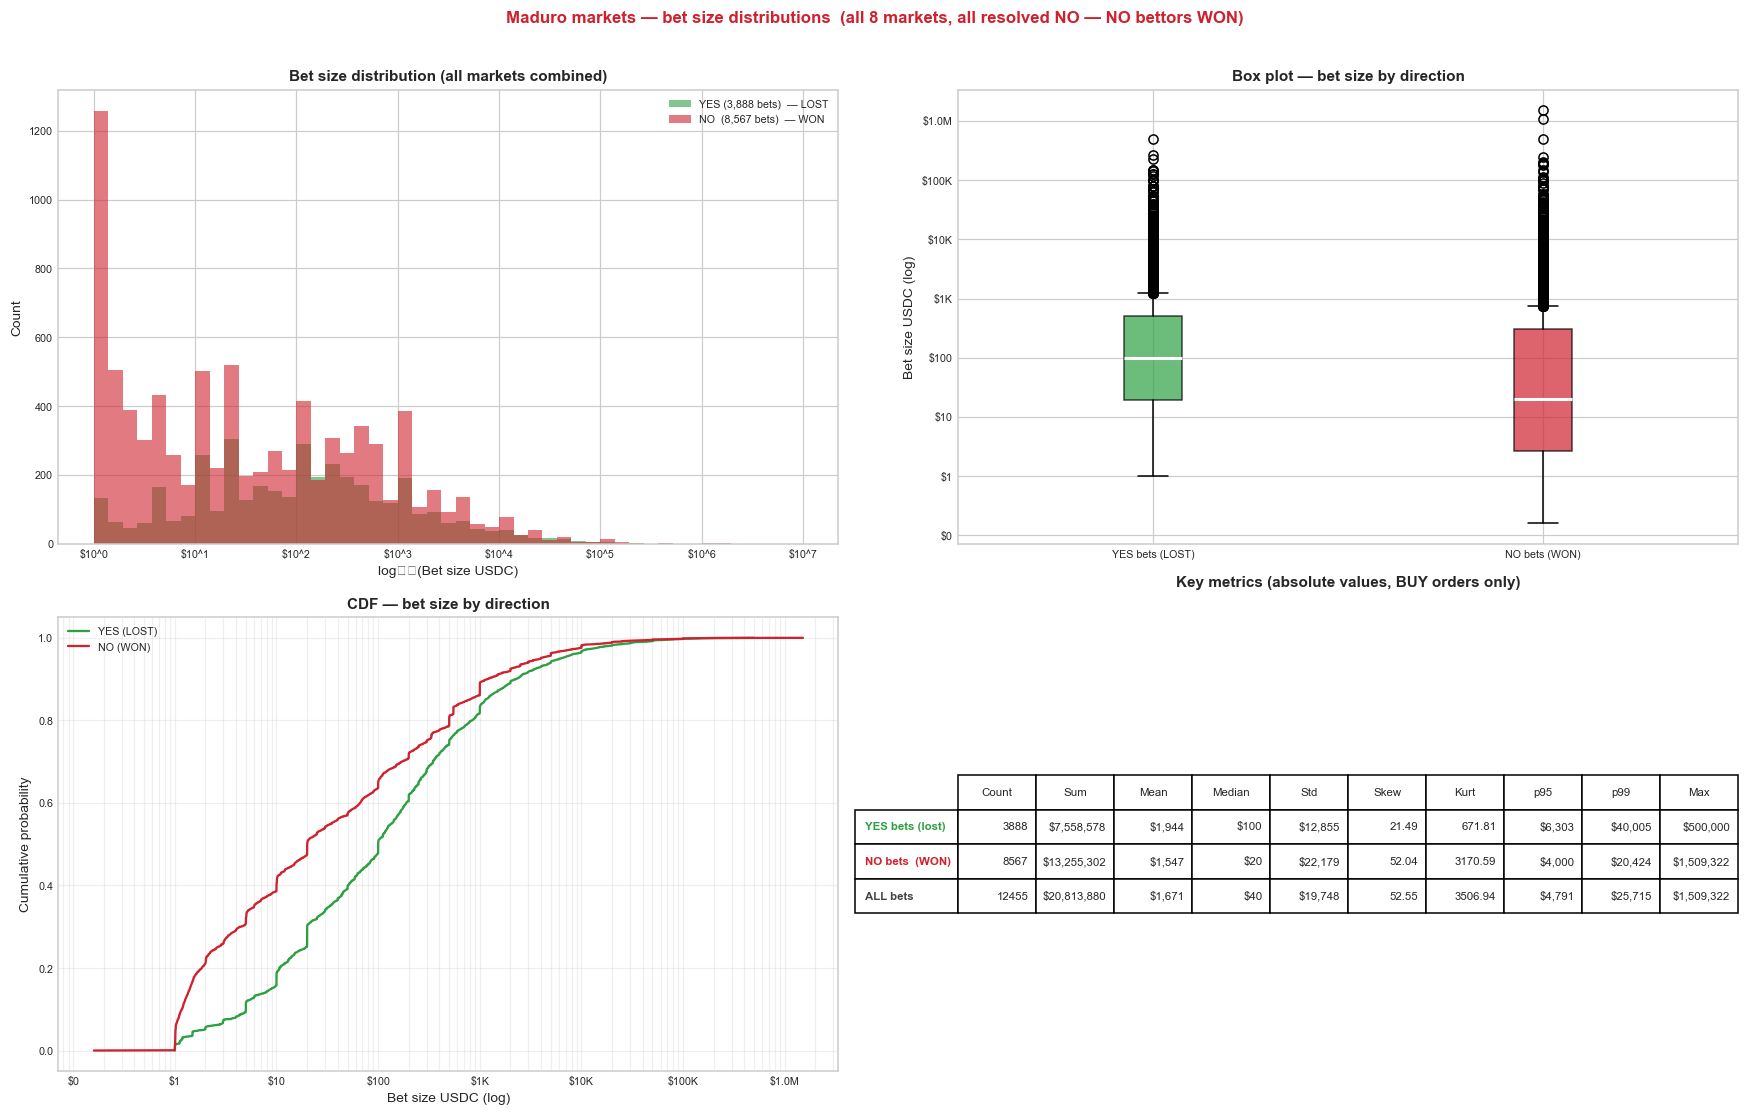

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Histogram of log10(size) ─────────────────────────────────────────────
ax = axes[0, 0]
bins = np.linspace(0, 7, 50)
ax.hist(np.log10(yes_sizes[yes_sizes > 0]), bins=bins,
        color=C_YES, alpha=0.6, label=f'YES ({len(yes_sizes):,} bets)  — LOST')
ax.hist(np.log10(no_sizes[no_sizes > 0]),   bins=bins,
        color=C_NO,  alpha=0.6, label=f'NO  ({len(no_sizes):,} bets)  — WON')
ax.set_xlabel('log₁₀(Bet size USDC)')
ax.set_ylabel('Count')
ax.set_title('Bet size distribution (all markets combined)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'$10^{int(round(v))}'))
ax.legend()

# ── Box plot ─────────────────────────────────────────────────────────────
ax = axes[0, 1]
bp = ax.boxplot([yes_sizes, no_sizes], patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(C_YES); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(C_NO);  bp['boxes'][1].set_alpha(0.7)
ax.set_xticks([1, 2])
ax.set_xticklabels(['YES bets (LOST)', 'NO bets (WON)'])
ax.set_yscale('log')
ax.yaxis.set_major_formatter(fmt_usdc)
ax.set_title('Box plot — bet size by direction', fontweight='bold')
ax.set_ylabel('Bet size USDC (log)')

# ── CDF ──────────────────────────────────────────────────────────────────
ax = axes[1, 0]
for sizes, col, lbl in [(np.sort(yes_sizes), C_YES, 'YES (LOST)'),
                         (np.sort(no_sizes),  C_NO,  'NO (WON)')]:
    if len(sizes):
        cdf = np.arange(1, len(sizes)+1) / len(sizes)
        ax.plot(sizes, cdf, color=col, linewidth=1.5, label=lbl)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(fmt_usdc)
ax.set_xlabel('Bet size USDC (log)')
ax.set_ylabel('Cumulative probability')
ax.set_title('CDF — bet size by direction', fontweight='bold')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

# ── Stats summary text ───────────────────────────────────────────────────
ax = axes[1, 1]
ax.axis('off')
tbl_data = []
metrics = ['Count','Sum','Mean','Median','Std','Skew','Kurt','p95','p99','Max']
for r in rows_stats:
    tbl_data.append([r[k] for k in metrics])
labels = [r['Label'] for r in rows_stats]
tbl = ax.table(
    cellText=tbl_data,
    rowLabels=labels,
    colLabels=metrics,
    loc='center', cellLoc='right'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1, 1.6)
# Colour row labels
for i, col in enumerate([C_YES, C_NO, '#444']):
    tbl[(i+1, -1)].set_text_props(color=col, fontweight='bold')
ax.set_title('Key metrics (absolute values, BUY orders only)', fontweight='bold', pad=20)

plt.suptitle('Maduro markets — bet size distributions  '
             '(all 8 markets, all resolved NO — NO bettors WON)',
             fontsize=11, fontweight='bold', color=C_NO, y=1.01)
plt.tight_layout()
plt.show()

## Per-market distribution — YES vs NO side by side

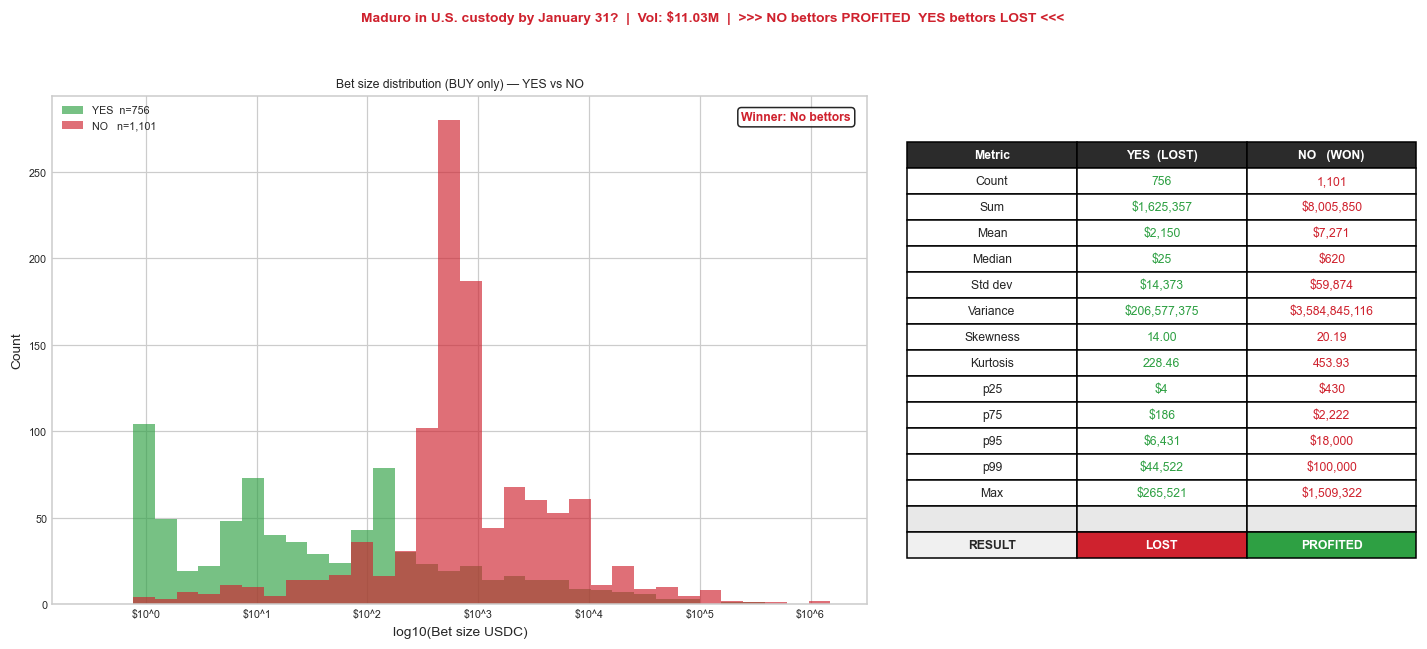

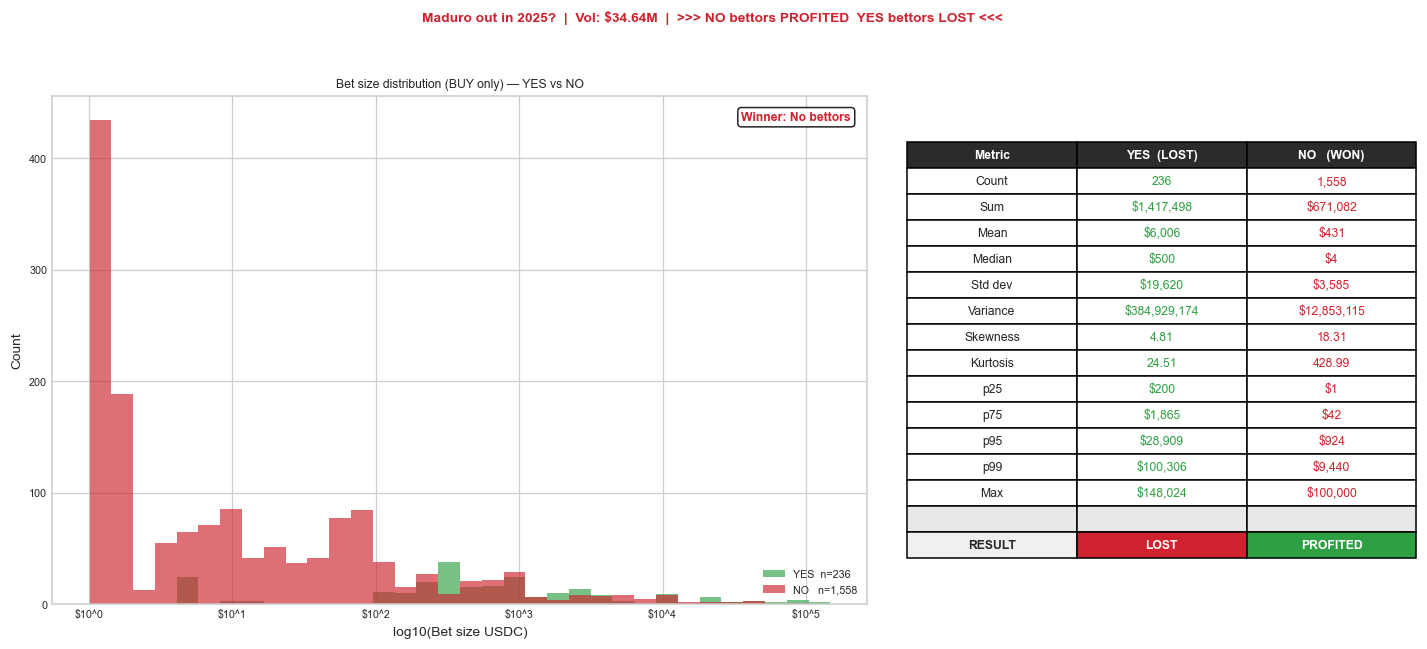

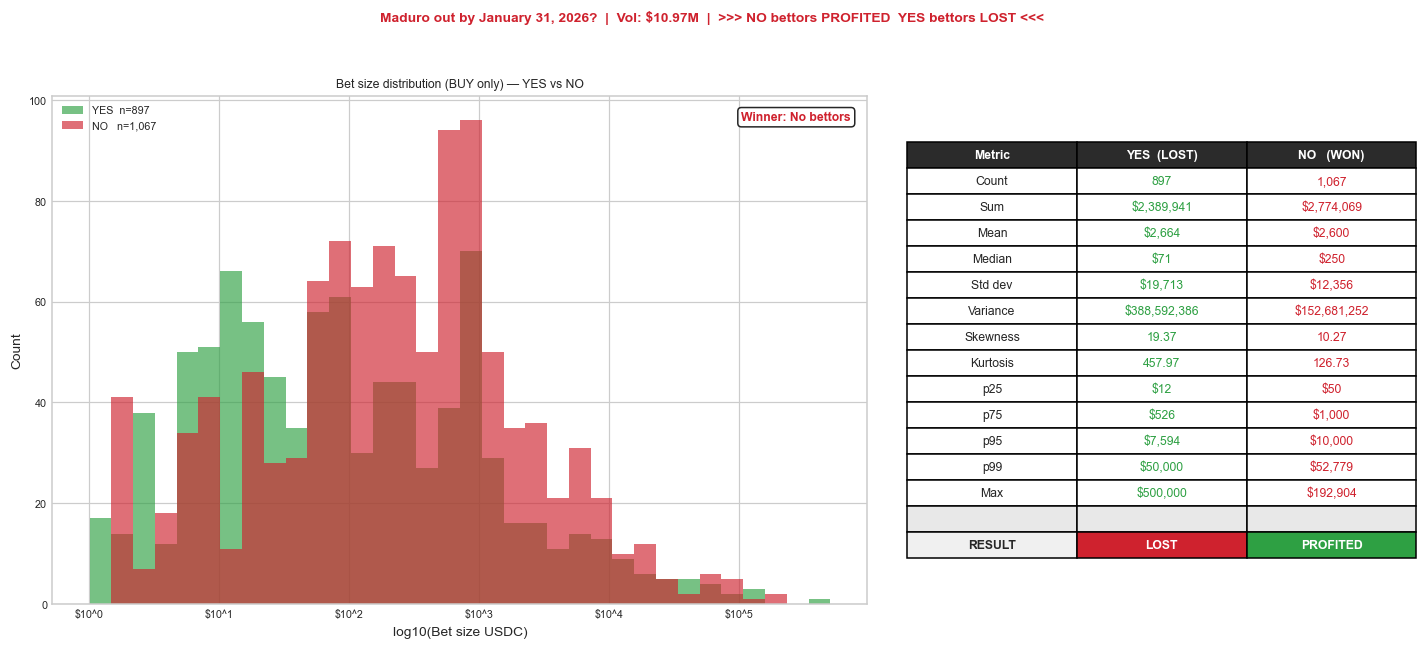

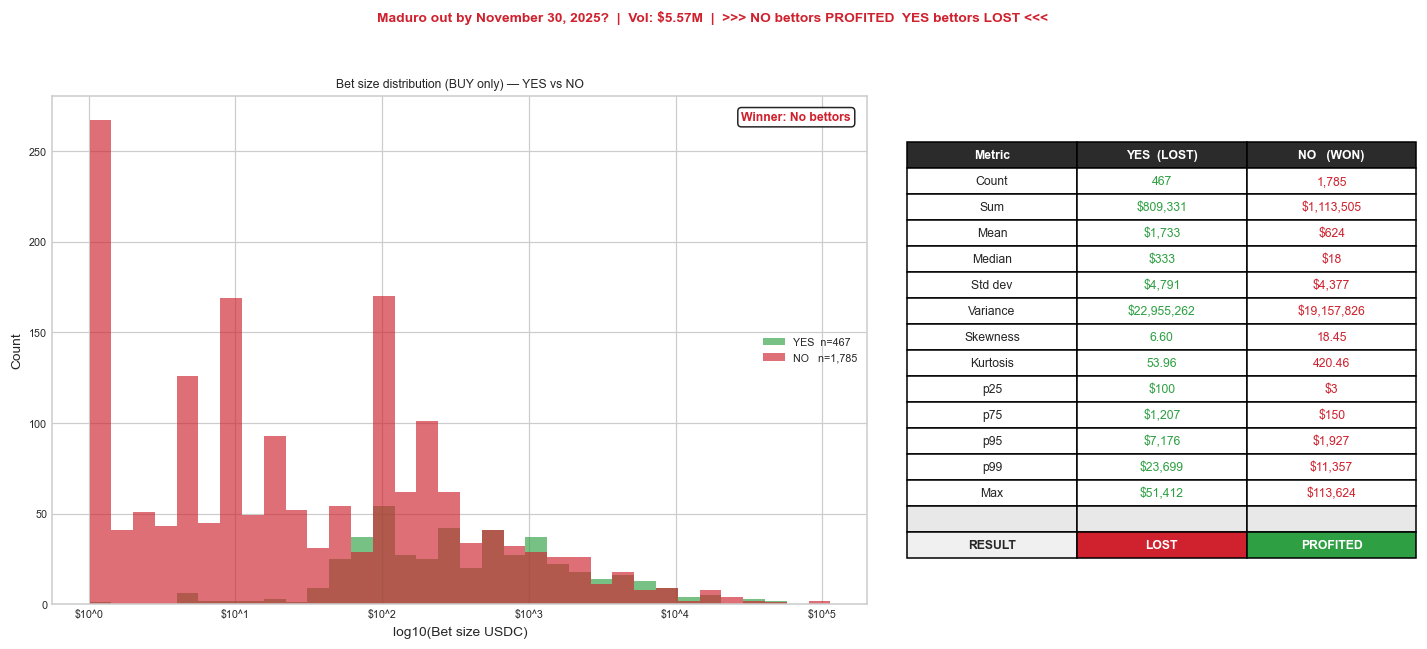

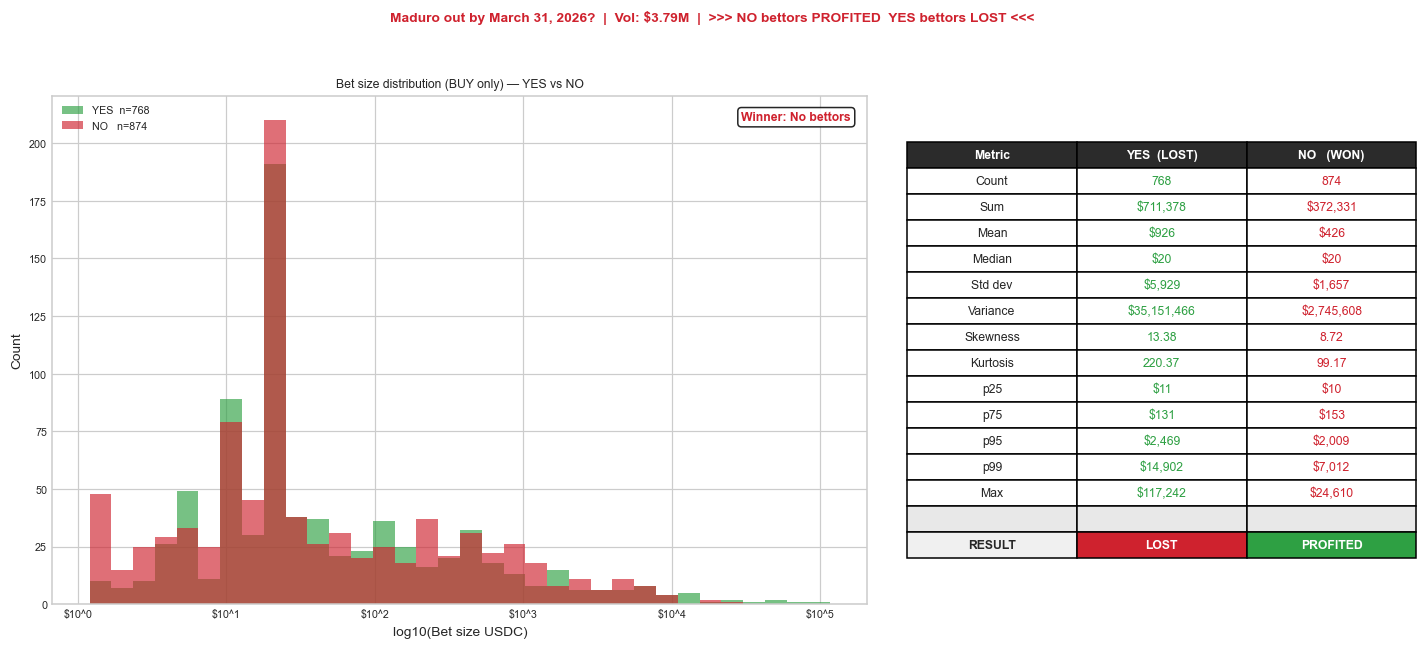

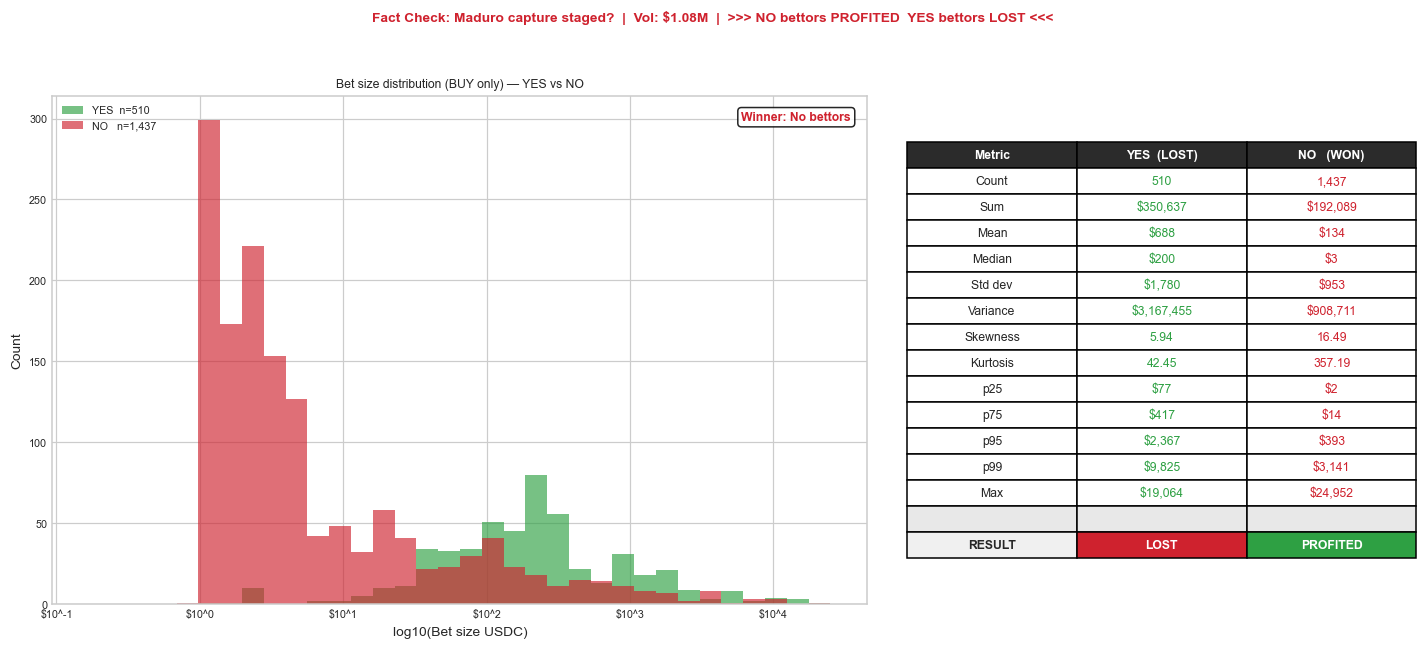

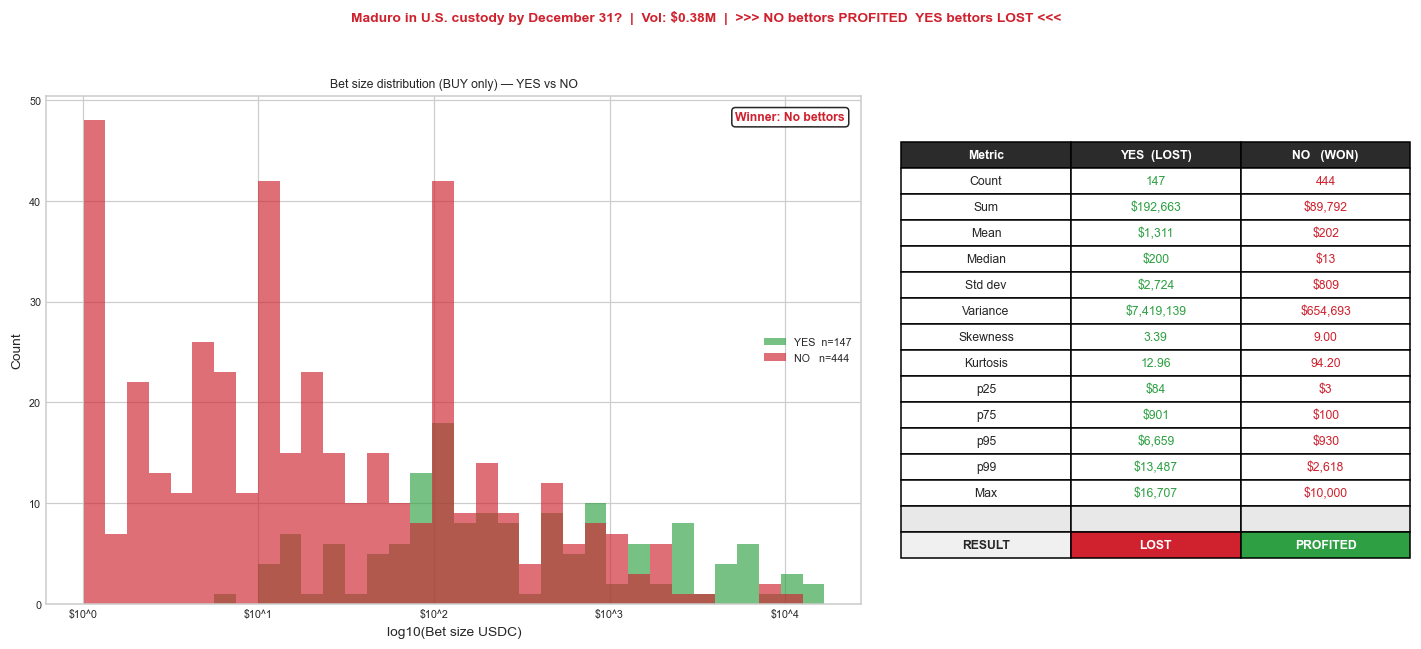

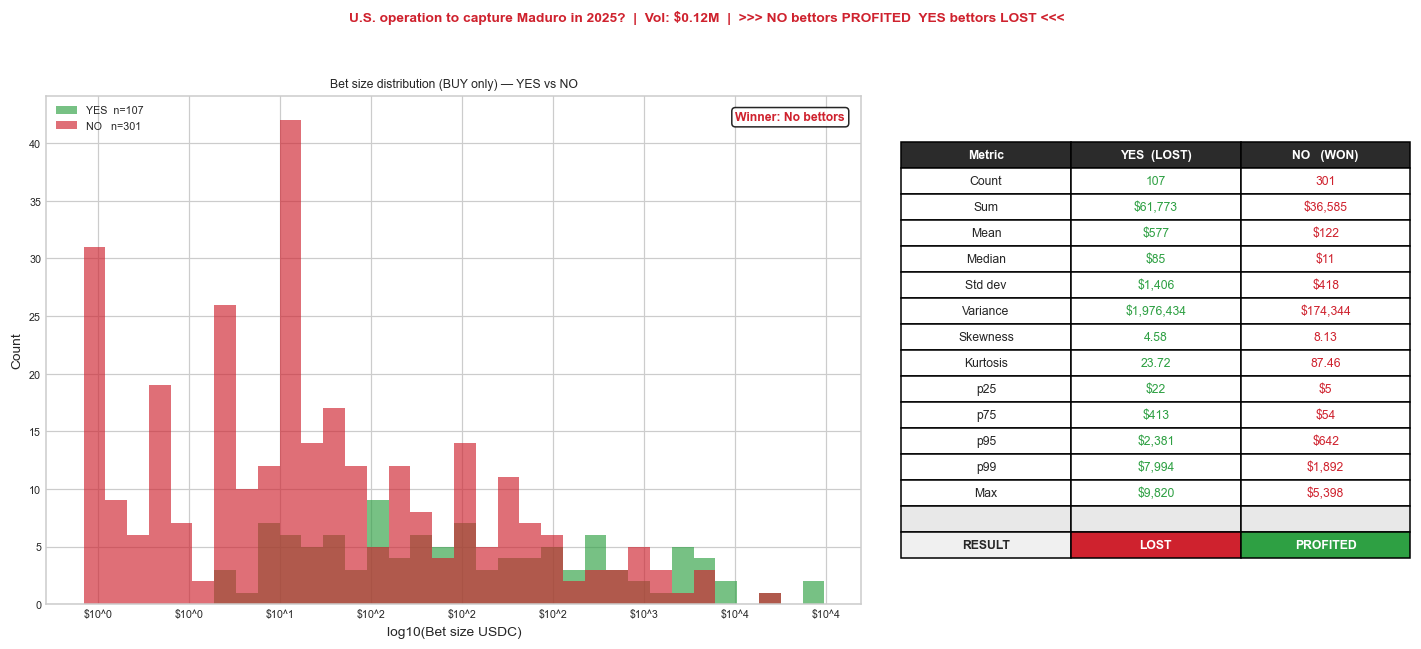

In [7]:
from scipy import stats as scipy_stats

for mkt in MARKETS:
    mkt_df  = buys.filter(pl.col('market') == mkt['question'])
    ys = np.abs(mkt_df.filter(pl.col('outcome')=='Yes')['size'].to_numpy())
    ns = np.abs(mkt_df.filter(pl.col('outcome')=='No' )['size'].to_numpy())
    res     = mkt['resolution']
    yes_won = (res == 'Yes')
    c_w     = C_YES if yes_won else C_NO
    winner  = 'YES' if yes_won else 'NO'
    loser   = 'NO'  if yes_won else 'YES'

    def fmt(a):
        return f'${a:,.0f}' if not (hasattr(a,'__float__') and __import__('math').isnan(float(a))) else 'n/a'

    fig = plt.figure(figsize=(16, 6))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1.6, 1], wspace=0.06)
    ax_hist = fig.add_subplot(gs[0])
    ax_tbl  = fig.add_subplot(gs[1])

    fig.suptitle(
        mkt['question'] + f'  |  Vol: ${mkt["volume_m"]:.2f}M  |  >>> {winner} bettors PROFITED  {loser} bettors LOST <<<',
        fontsize=9, fontweight='bold', color=c_w, y=1.01
    )

    # Histogram
    all_v = np.concatenate([ys[ys>0], ns[ns>0]])
    if len(all_v):
        bins = np.linspace(np.log10(all_v.min()+0.01), np.log10(all_v.max()+1), 35)
        if len(ys[ys>0]):
            ax_hist.hist(np.log10(ys[ys>0]), bins=bins, color=C_YES, alpha=0.65, label=f'YES  n={len(ys):,}')
        if len(ns[ns>0]):
            ax_hist.hist(np.log10(ns[ns>0]), bins=bins, color=C_NO,  alpha=0.65, label=f'NO   n={len(ns):,}')

    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: '$10^' + str(int(round(v)))))
    ax_hist.set_xlabel('log10(Bet size USDC)')
    ax_hist.set_ylabel('Count')
    ax_hist.set_title('Bet size distribution (BUY only) — YES vs NO', fontsize=8)
    ax_hist.legend(fontsize=7)
    ax_hist.text(0.98, 0.97, f'Winner: {res} bettors',
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=8, fontweight='bold', color=c_w,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    # Stats table
    ax_tbl.axis('off')

    yes_lbl = f'YES  ({"WON" if yes_won else "LOST"})'
    no_lbl  = f'NO   ({"WON" if not yes_won else "LOST"})'

    def st(a): return fmt(a.mean())        if len(a) else 'n/a'
    def md(a): return fmt(np.median(a))    if len(a) else 'n/a'
    def sd(a): return fmt(a.std())         if len(a) else 'n/a'
    def vr(a): return fmt(a.var())         if len(a) else 'n/a'
    def sk(a): return f'{scipy_stats.skew(a):.2f}' if len(a)>2 else 'n/a'
    def ku(a): return f'{scipy_stats.kurtosis(a):.2f}' if len(a)>2 else 'n/a'
    def pp(a, p): return fmt(np.percentile(a, p)) if len(a) else 'n/a'

    cell_data = [
        ['Count',    f'{len(ys):,}',              f'{len(ns):,}'],
        ['Sum',      fmt(ys.sum()) if len(ys) else 'n/a', fmt(ns.sum()) if len(ns) else 'n/a'],
        ['Mean',     st(ys),   st(ns)],
        ['Median',   md(ys),   md(ns)],
        ['Std dev',  sd(ys),   sd(ns)],
        ['Variance', vr(ys),   vr(ns)],
        ['Skewness', sk(ys),   sk(ns)],
        ['Kurtosis', ku(ys),   ku(ns)],
        ['p25',      pp(ys,25),pp(ns,25)],
        ['p75',      pp(ys,75),pp(ns,75)],
        ['p95',      pp(ys,95),pp(ns,95)],
        ['p99',      pp(ys,99),pp(ns,99)],
        ['Max',      fmt(ys.max()) if len(ys) else 'n/a', fmt(ns.max()) if len(ns) else 'n/a'],
        ['', '', ''],
        ['RESULT',   'PROFITED' if yes_won else 'LOST', 'PROFITED' if not yes_won else 'LOST'],
    ]

    tbl = ax_tbl.table(
        cellText=cell_data,
        colLabels=['Metric', yes_lbl, no_lbl],
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.42)

    for j in range(3):
        tbl[(0,j)].set_facecolor('#2b2b2b')
        tbl[(0,j)].set_text_props(color='white', fontweight='bold')

    for i, row in enumerate(cell_data, 1):
        tbl[(i,1)].set_text_props(color=C_YES)
        tbl[(i,2)].set_text_props(color=C_NO)
        if row[0] == '':
            for j in range(3):
                tbl[(i,j)].set_facecolor('#e8e8e8')
                tbl[(i,j)].set_text_props(color='#e8e8e8')
        if row[0] == 'RESULT':
            win_j = 1 if yes_won else 2
            los_j = 2 if yes_won else 1
            tbl[(i, win_j)].set_facecolor(C_YES)
            tbl[(i, win_j)].set_text_props(color='white', fontweight='bold')
            tbl[(i, los_j)].set_facecolor(C_NO)
            tbl[(i, los_j)].set_text_props(color='white', fontweight='bold')
            tbl[(i, 0)].set_facecolor('#f0f0f0')
            tbl[(i, 0)].set_text_props(fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Whale analysis — top 20 bets across all markets

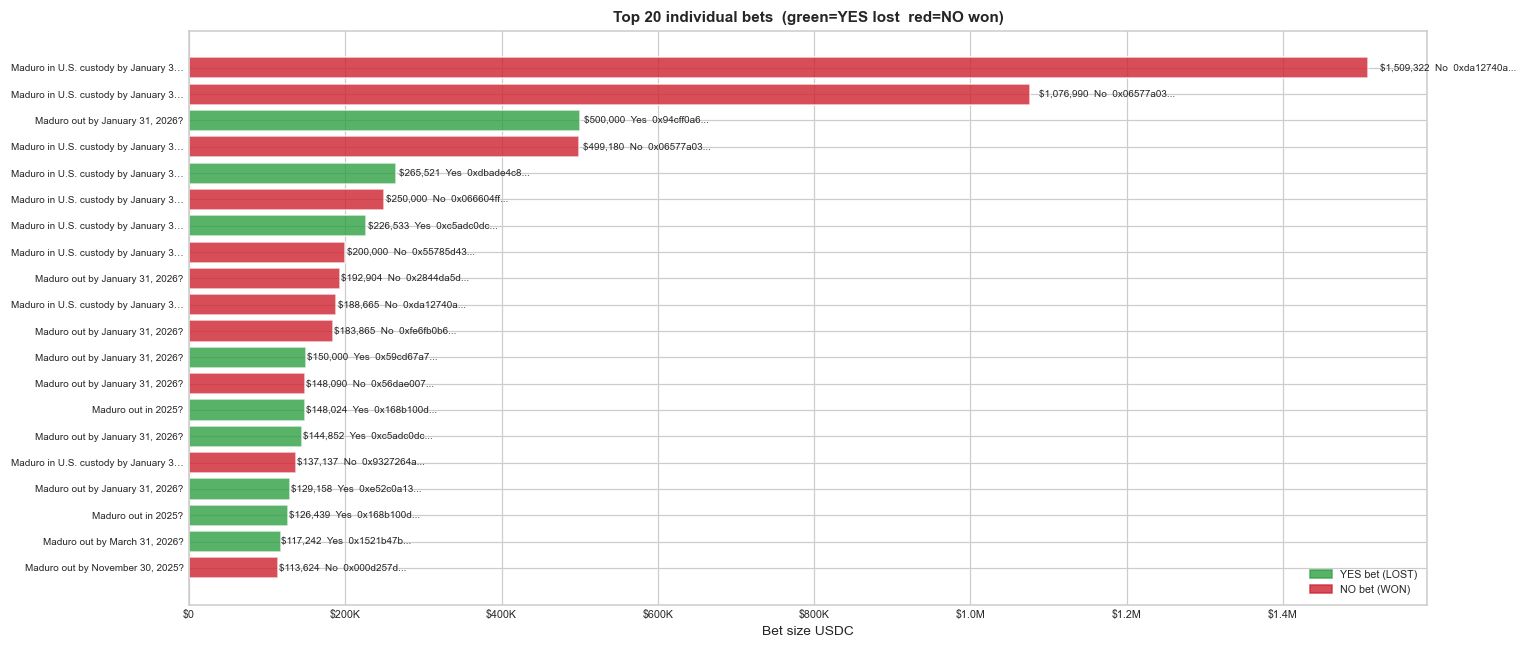


Saved: maduro_bets.csv
Total rows in CSV: 18,814


In [8]:
from datetime import datetime

top20 = buys.sort('size', descending=True).head(20)

fig, ax = plt.subplots(figsize=(14, 6))

for i, r in enumerate(top20.iter_rows(named=True)):
    col = C_YES if r['outcome'] == 'Yes' else C_NO
    ax.barh(i, r['size'], color=col, alpha=0.8, edgecolor='white')
    lbl = f"\${r['size']:,.0f}  {r['outcome']}  {r['wallet'][:10]}..."
    ax.text(r['size'] * 1.01, i, lbl, va='center', fontsize=6.5)

mkt_labels = [r['market'][:35] + '…' if len(r['market'])>35 else r['market']
              for r in top20.iter_rows(named=True)]
ax.set_yticks(range(20))
ax.set_yticklabels(mkt_labels, fontsize=6.5)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(fmt_usdc)
ax.set_xlabel('Bet size USDC')
ax.set_title('Top 20 individual bets  (green=YES lost  red=NO won)',
             fontweight='bold')
yes_p = mpatches.Patch(color=C_YES, label='YES bet (LOST)', alpha=0.8)
no_p  = mpatches.Patch(color=C_NO,  label='NO bet (WON)',  alpha=0.8)
ax.legend(handles=[yes_p, no_p])
plt.tight_layout()
plt.show()

print(f'\nSaved: {EDA / "maduro_bets.csv"}')
print(f'Total rows in CSV: {len(df):,}')